In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

In [2]:
d = pd.read_csv('../data/raw/training.csv')

In [3]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650698 entries, 0 to 650697
Data columns (total 8 columns):
Unnamed: 0        650698 non-null int64
contactId         650698 non-null int64
contactStart      650698 non-null object
campaignId        650698 non-null int64
abandoned         650698 non-null int64
abandonseconds    650698 non-null int64
inQueueSeconds    650698 non-null int64
agentSeconds      650698 non-null int64
dtypes: int64(7), object(1)
memory usage: 39.7+ MB


In [4]:
# d['agentSeconds'].replace(0, np.NaN,inplace=True)
# d.dropna(inplace=True)

In [5]:
# Create timestamp interval
temp_callstart = []
for i in d['contactStart'].astype('datetime64[ns]'):
    if i.minute < 30:
        lt = i.replace(minute=0, second=0, microsecond=0)
        temp_callstart.append(lt)
    elif i.minute >= 30:
        gte = i.replace(minute=30, second=0, microsecond=0)
        temp_callstart.append(gte)

d['timestamp'] = temp_callstart

In [6]:
# Query groups

call_volume = d.groupby(['timestamp'])['contactStart'].count()
avg_handle_time = d.groupby(['timestamp'])['agentSeconds'].mean()
abanded_count = d.groupby(['timestamp'])['abandoned'].count()
avg_aband_sec = d.groupby(['timestamp'])['abandonseconds'].mean()
avg_inQueue_sec = d.groupby(['timestamp'])['inQueueSeconds'].mean()

campaign_id = d.groupby(['timestamp'])['campaignId'].count()

In [7]:
CV = [] # Call volume
for i in call_volume:
    CV.append(i)
    
AHT = []
for i in avg_handle_time:
    AHT.append(i)
    
aband = []
for i in abanded_count:
    aband.append(i)
    
abandSec = []
for i in avg_aband_sec:
    abandSec.append(i)
    
inQueueSec = []
for i in avg_inQueue_sec:
    inQueueSec.append(i)
    
cmpgnid = []
for i in campaign_id:
        cmpgnid.append(i)

***

In [8]:
# New Dateframe
train = pd.DataFrame()
train['CV'] = CV
train['time'] = d['timestamp'].unique()
train['AHT'] = AHT
train['abandoned'] = aband
train['avgAbandSec'] = abandSec
train['inQueueSec'] = inQueueSec
train['campaignid'] = cmpgnid

In [9]:
print(f'Dimsension: {train.shape}')

Dimsension: (3035, 7)


In [10]:
train['AHT'].replace(0, np.NaN,inplace=True)
train.dropna(inplace=True)

In [11]:
print(f'Dimsension: {train.shape}')

Dimsension: (1843, 7)


In [12]:
train['minute'] = train.time.dt.minute
train['hour'] = train.time.dt.hour
train['day'] = train.time.dt.dayofweek
train['week'] = train.time.dt.week
train['time24'] = train.time.dt.time.astype('category')

**Campaign ID (Assuming it is uniqiue to angent)**

Possible indication that call center is understaffed during last hour till closing operations.

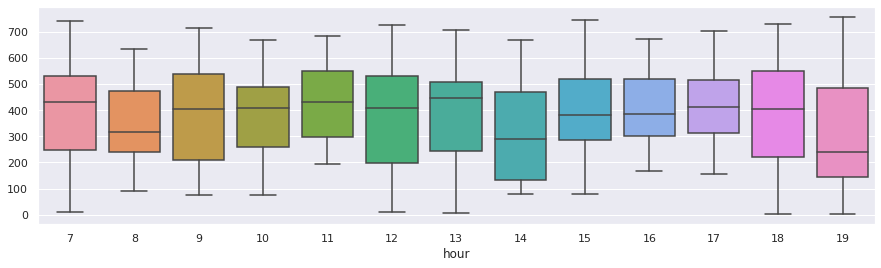

In [13]:
plt.subplots(figsize=(15, 4))
sns.boxplot(train['hour'], train['campaignid'].unique())
plt.show()

The mean of unique() campaign id's mean seems to be significantly less than other hours during the day.  Perhaps the call center could improve operations extra staff were available to answer calls.

Although, this observation is rather unrelevant in explaining the lower average handling times for this hour.  This would have to be further observed.

**Call Volume Boxplots**

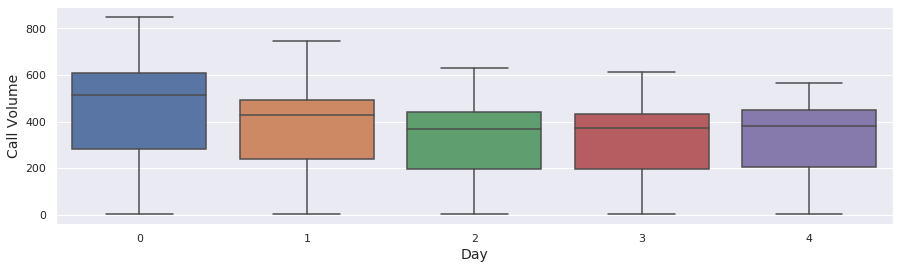

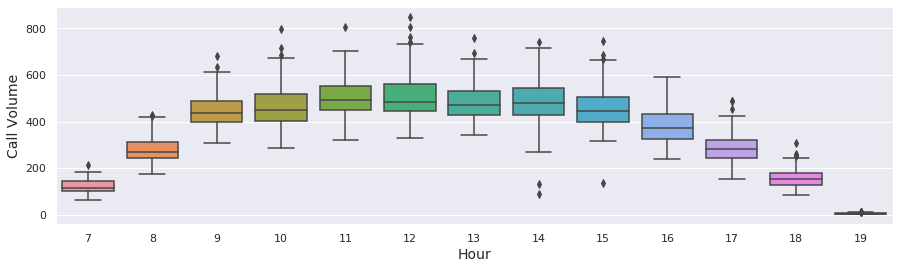

In [14]:
plt.subplots(figsize=(15, 4))
sns.boxplot(train['day'], train['CV'])
plt.xlabel('Day', fontsize=14)
plt.ylabel('Call Volume', fontsize=14)
plt.show()

plt.subplots(figsize=(15, 4))
sns.boxplot(train['hour'], train['CV'])
plt.xlabel('Hour', fontsize=14)
plt.ylabel('Call Volume', fontsize=14)
plt.show()

*** 

**Average Handling Time Boxplots**

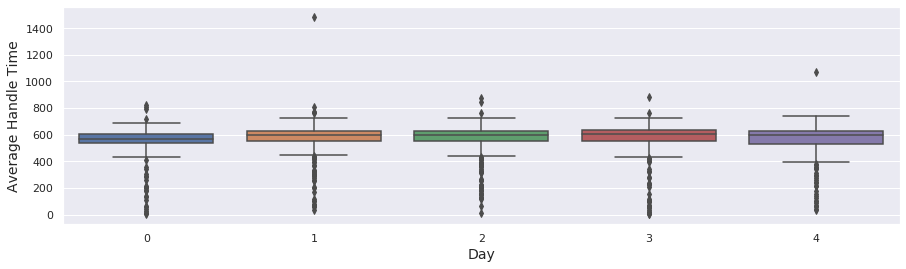

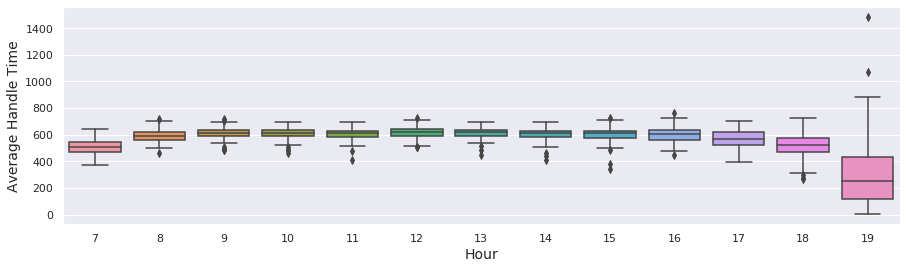

In [15]:
plt.subplots(figsize=(15, 4))
sns.boxplot(train['day'], train['AHT'])
plt.xlabel('Day', fontsize=14)
plt.ylabel('Average Handle Time', fontsize=14)
plt.show()

plt.subplots(figsize=(15, 4))
sns.boxplot(train['hour'], train['AHT'])
plt.xlabel('Hour', fontsize=14)
plt.ylabel('Average Handle Time', fontsize=14)
plt.show()

*** 

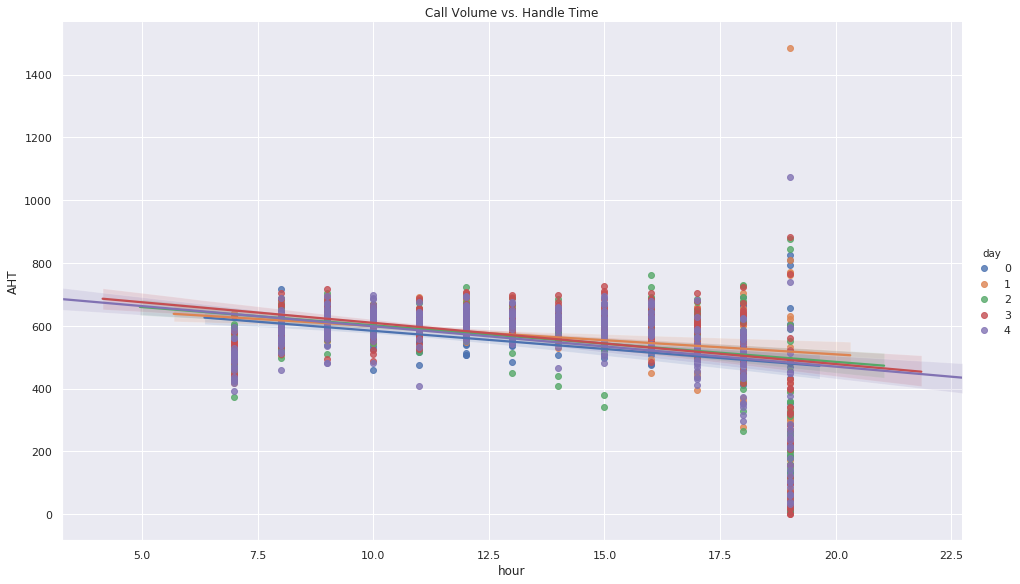

In [16]:
# sns.lmplot(x='AHT', y='CV', data=train,
#            fit_reg=True, hue='day', height=8, aspect=1.7)
# plt.title('Call Volume vs. Handle Time')
# plt.show()

# sns.lmplot(x='hour', y='CV', data=train,
#            fit_reg=True, hue='day', height=8, aspect=1.7)
# plt.title('Call Volume vs. Handle Time')
# plt.show()

sns.lmplot(x='hour', y='AHT', data=train,
           fit_reg=True, hue='day', height=8, aspect=1.7)
plt.title('Call Volume vs. Handle Time')
plt.show()

***

**Removing significant Average Handling Time**

In [17]:
# Remove AHT outliers
train['AHT'][train['AHT'] < 200] = np.NaN
train['AHT'][train['AHT'] > 800] = np.NaN
train['AHT'].isnull().sum()
train.dropna(inplace=True)

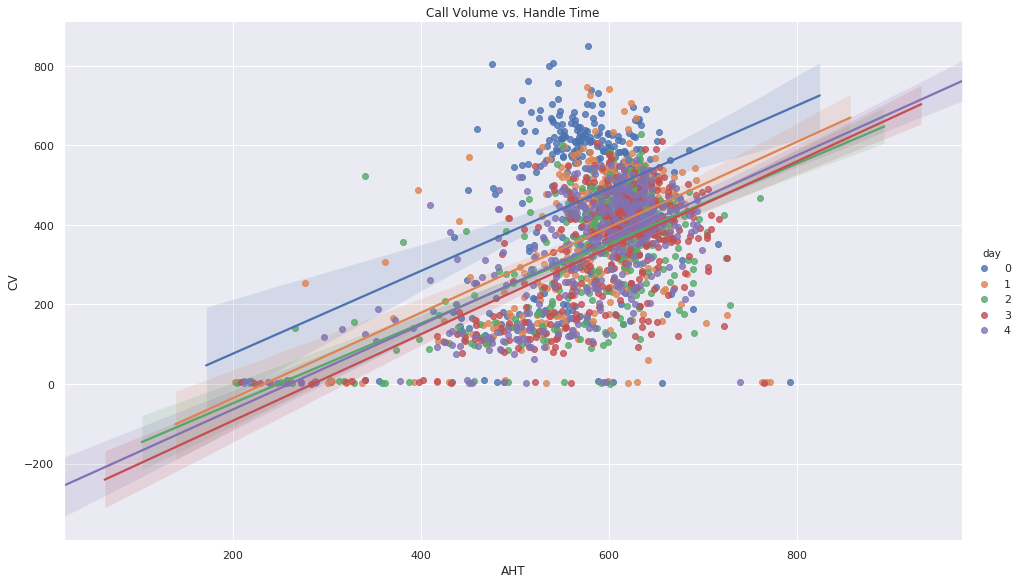

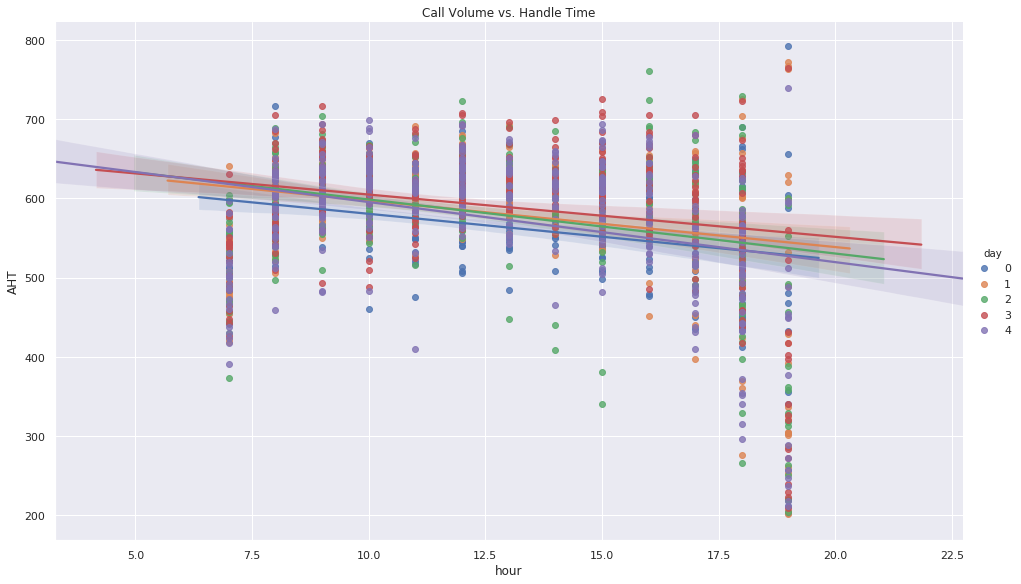

In [18]:
sns.lmplot(x='AHT', y='CV', data=train,
           fit_reg=True, hue='day', height=8, aspect=1.7)
plt.title('Call Volume vs. Handle Time')
plt.show()

sns.lmplot(x='hour', y='AHT', data=train,
           fit_reg=True, hue='day', height=8, aspect=1.7)
plt.title('Call Volume vs. Handle Time')
plt.show()

In [19]:
# Output CSV to begin modeling
train.to_csv('../data/interim/02training.csv')